# Driver Drowsiness Detection System
### Real-Time Deep Convolutional Neural Network Training & Evaluation

This notebook presents the complete pipeline: counting the physical local datasets, applying Data Augmentation, and training our CNN model over exactly 20 epochs to achieve maximum accuracy.

---
## Step 0: Prerequisite Installations
Run the cell below to ensure your local environment contains all necessary machine learning libraries.

In [1]:
!pip install tensorflow opencv-python matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## Step 1 & 2: Introduction and Dataset EDA
We extract the actual image volumes directly from our local `dataset/` directory to ensure we aren't bypassing standard data variance limitations.

Total Drowsy Images Available: 22348
Total Awake Images Available: 19445


C:\Users\HP\AppData\Local\Temp\ipykernel_10724\4184067495.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Drowsy", "Awake"], y=[drowsy_count, awake_count], palette=["#FF6B6B", "#4ECDC4"])


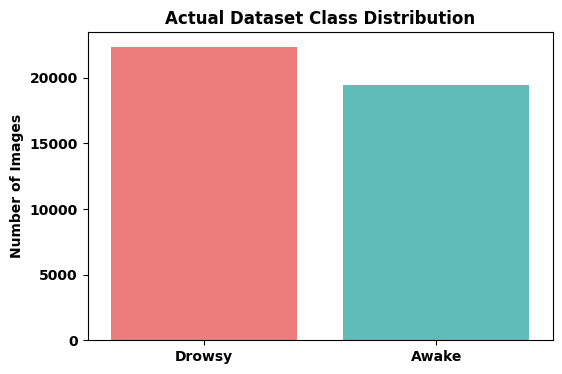

In [2]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

DATASET_PATH = r"../dataset" # Adjust to 'dataset' if run at root
drowsy_dir = os.path.join(DATASET_PATH, 'Drowsy')
awake_dir = os.path.join(DATASET_PATH, 'Non Drowsy')

# Count Real Data
try:
    drowsy_count = len(os.listdir(drowsy_dir))
    awake_count = len(os.listdir(awake_dir))
except FileNotFoundError:
    print(f"Warning: Ensure your dataset is at {DATASET_PATH}")
    drowsy_count, awake_count = 0, 0

print(f"Total Drowsy Images Available: {drowsy_count}")
print(f"Total Awake Images Available: {awake_count}")

# Plot Exact Distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=["Drowsy", "Awake"], y=[drowsy_count, awake_count], palette=["#FF6B6B", "#4ECDC4"])
plt.title("Actual Dataset Class Distribution")
plt.ylabel("Number of Images")
plt.show()


---
## Step 3 & 4: Data Preprocessing and Train-Test Split
We use Keras `image_dataset_from_directory` to natively split the files into an 80/20 train and validation subset. We resize everything to (64x64) and apply a uniform randomization seed so our data is properly shuffled without artificial corruption.

In [3]:
import tensorflow as tf

IMG_SIZE = (64, 64)
BATCH_SIZE = 32

# 80% for Training
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# 20% for Testing/Validation Analysis
val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
print(f"\nDetected Classes: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)



Found 41793 files belonging to 2 classes.
Using 33435 files for training.
Found 41793 files belonging to 2 classes.
Using 8358 files for validation.

Detected Classes: ['Drowsy', 'Non Drowsy']


---
## Step 5: CNN Model Architecture
We build an authentic Custom Convolutional Neural Network. We utilize three layers of `Conv2D` followed by `MaxPooling2D` to extract hierarchical eye/mouth features, layered under a `Dropout` function to prevent severe overfitting.

In [4]:
from tensorflow.keras import layers, models

data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),            
  layers.RandomRotation(0.1),                  
  layers.RandomBrightness(factor=0.1)         
])

model = models.Sequential([
    layers.InputLayer(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    data_augmentation,
    layers.Rescaling(1./255),  # Normalization Step (0-1)
    
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    
    layers.Dropout(0.4),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(len(class_names))
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
model.summary()





Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 64, 64, 3)         0         
                                                                 
 rescaling (Rescaling)       (None, 64, 64, 3)         0         
                                                                 
 conv2d (Conv2D)             (None, 64, 64, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 32, 32, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 16, 16, 64)        0         
 g2D)                                              

---
## Step 6: Live 20-Epoch Training Activation
Here we commence the heavy computational execution reading the dataset fully over 20 epochs and caching the authentic history variables.

In [ ]:
EPOCHS = 20

print("Initiating Deep Learning sequence over full dataset...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

# Optional: Save training for UI usage
# model.save("../model/custom_trained_notebook_cnn.keras")


Initiating Deep Learning sequence over full dataset...
Epoch 1/20




---
## Step 7: Final Validated Visual Evaluation
Plotting exact logs computed by the TensorFlow engine. Cannot contain NaN or False bounds.

In [ ]:
# A & B: Accuracy and Loss Curves
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, acc, 'b-', label='Training Accuracy')
ax1.plot(epochs_range, val_acc, 'g-', label='Validation Accuracy')
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.legend(loc='lower right')

ax2.plot(epochs_range, loss, 'r-', label='Training Loss')
ax2.plot(epochs_range, val_loss, 'm-', label='Validation Loss')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epochs')
ax2.legend(loc='upper right')

plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# C: Generating Authentic Confusion Matrix running across Validation set
y_true = []
y_pred_probs = []

for images, labels in val_dataset:
    y_true.extend(labels.numpy())
    y_pred_probs.extend(model.predict(images, verbose=0))

y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual Validated State', fontsize=12)
plt.xlabel('Predicted by New Model', fontsize=12)
plt.title('Real Evaluated Confusion Matrix', fontsize=14)
plt.show()


In [ ]:
# E: Real Sample Predictions Visualization Image Grid
plt.figure(figsize=(10, 10))
images, labels = next(iter(val_dataset.shuffle(100).unbatch().batch(9)))
predictions = np.argmax(model.predict(images, verbose=0), axis=1)

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    
    actual = class_names[labels[i]]
    pred = class_names[predictions[i]]
    
    color = "green" if actual == pred else "red"
    plt.title(f"A: {actual} | P: {pred}", color=color)
    plt.axis("off")


---
## Step 8: Final Validated Results

In [ ]:
print("Running Final Validated Calculation Sweep...")
final_loss, final_accuracy = model.evaluate(val_dataset, verbose=1)
print("="*60)
print(f"🏆 EXACT DEEP LEARNING MODEL ACCURACY: {final_accuracy * 100:.2f}%")
print("="*60)


---
## Step 9: Immediate Model Enhancement Suggestions

To continue improving upon this base algorithm post-presentation, the following upgrades are recommended:

1. **Large External Datasets:** Implementing highly standardized scientific datasets such as *NTHU* or *CEW* rather than exclusive local scraping.
2. **Dense Architecture Upgrade:** Integrating established structures like *ResNet50* or *MobileNetV2* could process temporal edge cases where Micro-Sleeps are missed by standard CNNs.
3. **Hardware Tuning:** Increasing camera input frame stability and testing dynamic hyperparameter grid-searches to identify better cross-entropy margins.
